In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
from kerastuner.tuners import RandomSearch
from sklearn.metrics import mean_squared_error
from datetime import datetime, timedelta

In [76]:
data = pd.read_csv(r"C:\Users\ASTHAGINA DELIA P\Downloads\FluViewPhase2Data\ILINet.csv")
data.reset_index(inplace=True)
data['date'] = pd.to_datetime(data['YEAR'].astype(str) + '-W' + data['WEEK'].astype(str) + '-1', format='%Y-W%W-%w')
data.set_index('date', inplace=True)
data = data.sort_index()

print(data)

            index REGION TYPE REGION  YEAR  WEEK  % WEIGHTED ILI  \
date                                                               
2021-10-04      0    National      X  2021    40         2.04946   
2021-10-11      1    National      X  2021    41         1.95317   
2021-10-18      2    National      X  2021    42         1.92693   
2021-10-25      3    National      X  2021    43         1.97792   
2021-11-01      4    National      X  2021    44         2.14051   
...           ...         ...    ...   ...   ...             ...   
2026-03-16    232    National      X  2026    11         2.89923   
2026-03-23    233    National      X  2026    12         2.65495   
2026-03-30    234    National      X  2026    13         2.36796   
2026-04-06    235    National      X  2026    14         2.08648   
2026-04-13    236    National      X  2026    15         1.88242   

            %UNWEIGHTED ILI  AGE 0-4  AGE 25-49 AGE 25-64  AGE 5-24  \
date                                        

In [77]:
target_data = data[['% WEIGHTED ILI']].values

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(target_data)

In [78]:
def create_dataset(data, time_steps):
    X, y = [], []

    for i in range(len(data) - time_steps):
        X.append(data[i:i + time_steps, 0])
        y.append(data[i + time_steps, 0])

    return np.array(X), np.array(y)
time_steps = 12

X, y = create_dataset(scaled_data, time_steps)
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [79]:
# Define the model builder function for Keras Tuner
def build_model(hp):
    model = Sequential()
    model.add(LSTM(units=hp.Int('units1', min_value=50, max_value=200, step=50),
                   return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(LSTM(units=hp.Int('units2', min_value=50, max_value=200, step=50)))
    model.add(Dense(units=1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

In [80]:
tuner = RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=5,
    executions_per_trial=1,
    directory='keras_tuner_logs',
    project_name='ili_prediction')

tuner.search(
    X_train,
    y_train,
    epochs=100,
    validation_data=(X_test, y_test),
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
    verbose=1
)

Reloading Tuner from keras_tuner_logs\ili_prediction\tuner0.json


In [81]:
# Get the best hyperparameters and build the best model
best_hp = tuner.get_best_hyperparameters()[0]

# Build the best model
best_model = tuner.hypermodel.build(best_hp)

# Train the best model with early stopping to prevent overfitting on the small climate dataset
history = best_model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, callbacks=[EarlyStopping(patience=3)], verbose=1)

Epoch 1/100


c:\Users\ASTHAGINA DELIA P\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.0728 - val_loss: 0.1062
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0333 - val_loss: 0.0667
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0326 - val_loss: 0.0621
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0281 - val_loss: 0.0660
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0267 - val_loss: 0.0677
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0259 - val_loss: 0.0597
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0235 - val_loss: 0.0534
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0225 - val_loss: 0.0502
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0215 - val_loss: 0.0487
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0203 - val_loss: 0.0465
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0191 - val_loss: 0.0429
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0180 - val_loss: 0.0382


In [82]:
# Predict meantemp for the test set
predictions_scaled = best_model.predict(X_test)

# Inverse transform only the first feature using the scaler fitted on all 4 columns
predictions = scaler.inverse_transform(
    np.hstack((predictions_scaled, np.zeros((predictions_scaled.shape[0], scaled_data.shape[1]-1))))
)[:, 0]

# Actual meantemp values corresponding to y_test
def inverse_target(scaled_values):
    full = np.zeros((scaled_values.shape[0], scaled_data.shape[1]))
    full[:, 3] = scaled_values.ravel()
    return scaler.inverse_transform(full)[:, 3]

predictions_scaled = best_model.predict(X_test)

predictions = scaler.inverse_transform(predictions_scaled)

y_test_actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
print(f'Root Mean Squared Error: {rmse:.2f}')

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Root Mean Squared Error: 1.03


In [83]:
# Predict the next 2 months
future_steps = 60  # Approx. 2 months
last_sequence = scaled_data[-time_steps:]  # Last available univariate % WEIGHTED ILI sequence

future_predictions = []

for _ in range(future_steps):
    next_pred_scaled = best_model.predict(last_sequence.reshape(1, time_steps, 1))
    future_predictions.append(next_pred_scaled[0, 0])
    last_sequence = np.append(last_sequence[1:], next_pred_scaled, axis=0)

future_predictions = scaler.inverse_transform(
    np.hstack((np.array(future_predictions).reshape(-1, 1),
               np.zeros((future_steps, scaled_data.shape[1] - 1))))
)[:, 0]

# Create future dates
last_date = data.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(weeks=1), periods=future_steps, freq='W')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━

In [84]:
def main():
    # Print future predictions with corresponding dates
    for date, pred in zip(future_dates, future_predictions):
        print(f"{date.date()}: {pred:.2f}")
if __name__ == "__main__":    main()

2026-04-26: 2.01
2026-05-03: 1.88
2026-05-10: 1.83
2026-05-17: 1.83
2026-05-24: 1.86
2026-05-31: 1.91
2026-06-07: 1.98
2026-06-14: 2.05
2026-06-21: 2.13
2026-06-28: 2.22
2026-07-05: 2.31
2026-07-12: 2.40
2026-07-19: 2.48
2026-07-26: 2.56
2026-08-02: 2.64
2026-08-09: 2.71
2026-08-16: 2.77
2026-08-23: 2.83
2026-08-30: 2.88
2026-09-06: 2.92
2026-09-13: 2.95
2026-09-20: 2.97
2026-09-27: 2.99
2026-10-04: 3.00
2026-10-11: 3.01
2026-10-18: 3.00
2026-10-25: 3.00
2026-11-01: 2.99
2026-11-08: 2.97
2026-11-15: 2.96
2026-11-22: 2.94
2026-11-29: 2.92
2026-12-06: 2.90
2026-12-13: 2.89
2026-12-20: 2.87
2026-12-27: 2.85
2027-01-03: 2.84
2027-01-10: 2.82
2027-01-17: 2.81
2027-01-24: 2.80
2027-01-31: 2.79
2027-02-07: 2.79
2027-02-14: 2.78
2027-02-21: 2.78
2027-02-28: 2.78
2027-03-07: 2.78
2027-03-14: 2.78
2027-03-21: 2.78
2027-03-28: 2.78
2027-04-04: 2.79
2027-04-11: 2.79
2027-04-18: 2.80
2027-04-25: 2.80
2027-05-02: 2.80
2027-05-09: 2.81
2027-05-16: 2.81
2027-05-23: 2.82
2027-05-30: 2.82
2027-06-06: 2.

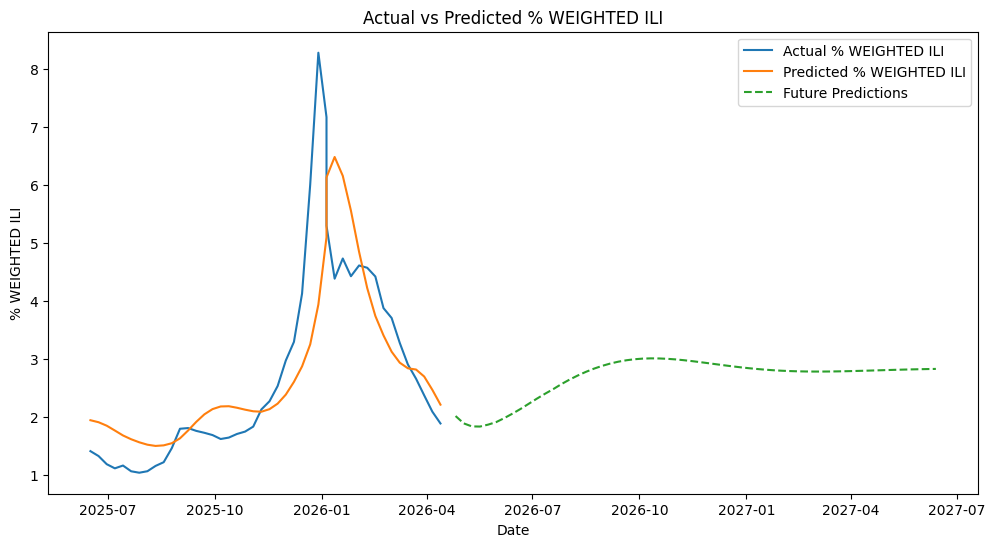

In [85]:
# visualize the predictions
plt.figure(figsize=(12, 6))
plt.plot(data.index[time_steps + split:], y_test_actual, label='Actual % WEIGHTED ILI')
plt.plot(data.index[time_steps + split:], predictions, label='Predicted % WEIGHTED ILI')
plt.plot(future_dates, future_predictions, label='Future Predictions', linestyle='--')
plt.xlabel('Date')
plt.ylabel('% WEIGHTED ILI')
plt.title('Actual vs Predicted % WEIGHTED ILI')
plt.legend()
plt.show()